# Trabalho Prático 2 — Pré-processamento e Análise Preditiva
## Notebook 3: Modelagem Preditiva (Etapas 2.1 a 2.7)

**Aluno:** João Victor Borges Carvalho  
**Base:** Breast Cancer Wisconsin (Original)  
**Abordagem:** Todos os algoritmos implementados do zero com Python puro + math  

Vou implementar quatro modelos de classificação completamente na mão — baseline, K-NN, Árvore C4.5 e Rede Neural MLP — e comparar os resultados.

A implementação da MLP foi de longe a parte mais trabalhosa. Backpropagation manual com regra da cadeia não é exatamente divertido de debugar, mas depois que funciona dá uma satisfação enorme.

## Configuração e Imports

Carrego todas as funções do `utils.py`: métricas, baseline, K-NN, C4.5 e MLP. O notebook é autocontido — se quiser pular direto pra cá sem reexecutar os anteriores, a célula de pipeline recarrega os dados do zero e reproduz tudo.

In [2]:
import os
import sys

PROJECT_DIR = os.path.dirname(os.path.abspath(''))
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

import matplotlib.pyplot as plt

from utils import (
    # Dados (recarregar se necessário)
    parse_dataset, count_target,
    stratified_split,
    remove_constant_columns, remove_duplicate_rows,
    normalize_minmax,
    feature_target_correlations,
    calc_mode,
    # Métricas
    confusion_matrix_values,
    calc_accuracy, calc_precision, calc_recall, calc_specificity, calc_f1_score,
    evaluate_model,
    # Baseline
    majority_class_baseline,
    # K-NN
    knn_predict_batch,
    # C4.5
    build_tree_c45, predict_tree_batch, count_tree_nodes,
    # MLP
    mlp_train, mlp_predict,
)

DATA_PATH = os.path.join('data', 'breast_cancer_wisconsin.csv')
PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

print('utils.py importado com sucesso.')

utils.py importado com sucesso.


## Recarregar e Pré-processar os Dados

Reproduzo todo o pipeline dos Notebooks 1 e 2 em uma célula só. Isso garante que o Notebook 3 funcione independentemente 

In [4]:
# ── Pipeline completo (equivalente aos Notebooks 1+2) ──

header, X, y, mask = parse_dataset(DATA_PATH)
feature_names_all = list(header[:-1])

# Filtrar válidos
X_valid = [X[i] for i in range(len(X)) if mask[i]]
y_valid = [y[i] for i in range(len(y)) if mask[i]]

# Split estratificado 80/20
X_train, X_test, y_train, y_test = stratified_split(X_valid, y_valid, test_ratio=0.2, seed=42)

# Remover duplicatas
X_clean, feature_names_clean, _ = remove_constant_columns(X_train, feature_names_all)
X_train_clean, y_train_clean, n_dup = remove_duplicate_rows(X_clean, y_train)

# Imputar teste com moda do treino
X_train_imputed = [list(row) for row in X_train_clean]
X_test_imputed = [list(row) for row in X_test]

# Normalizar
X_train_norm, mins, maxs = normalize_minmax(X_train_imputed)
X_test_norm = []
for row in X_test_imputed:
    new_row = []
    for col_idx, val in enumerate(row):
        denom = maxs[col_idx] - mins[col_idx]
        new_row.append((val - mins[col_idx]) / denom if denom != 0 else 0.0)
    X_test_norm.append(new_row)

# Features finais (todas mantidas — correlação > 0.10)
feature_names_final = list(feature_names_clean)
X_train_final = X_train_norm
X_test_final = X_test_norm

print(f'   Pipeline concluído:')
print(f'   Treino: {len(y_train_clean)} exemplos × {len(feature_names_final)} features')
print(f'   Teste:  {len(y_test)} exemplos × {len(feature_names_final)} features')
print(f'   Duplicatas removidas: {n_dup}')

   Pipeline concluído:
   Treino: 362 exemplos × 9 features
   Teste:  137 exemplos × 9 features
   Duplicatas removidas: 184


## Etapa 2.1 — Técnica de Validação

Uso o mesmo hold-out 80/20 estratificado da Etapa 5. Pensei em usar cross-validation, mas como estou implementando tudo na mão, o custo de rodar 5 folds × 3 algoritmos seria bem alto — e o ganho marginal não justificaria. Pra esse dataset (362 exemplos de treino) e esse escopo, o hold-out é suficiente.

## Etapa 2.2 — Métricas de Avaliação

Uso um conjunto completo de métricas:

- **Matriz de Confusão:** TP, TN, FP, FN (classe positiva = 1 = Maligno)
- **Acurácia:** quantos acertei no total
- **Precisão:** dos que classifiquei como malignos, quantos realmente são?
- **Recall (Sensibilidade):** dos malignos reais, quantos eu detectei? ← ESSA É A MAIS IMPORTANTE
- **Especificidade:** dos benignos, quantos classifiquei corretamente?
- **F1-Score:** média harmônica de precisão e recall → uso como métrica principal

No contexto de diagnóstico de câncer, o recall é a métrica mais crítica. Um falso negativo significa deixar um câncer passar despercebido — e isso pode ter consequências graves. O F1-Score equilibra precisão e recall num número só, por isso escolhi ele como critério de desempate.

In [4]:
print('Métricas implementadas do zero:')
print()
print('  1. Matriz de Confusão (TP, TN, FP, FN)')
print('     Classe Positiva = 1 (Maligno) | Negativa = 0 (Benigno)')
print('  2. Acurácia  = (TP + TN) / Total')
print('  3. Precisão  = TP / (TP + FP)')
print('  4. Recall    = TP / (TP + FN)  ← MAIS CRÍTICA no contexto médico')
print('  5. Especificidade = TN / (TN + FP)')
print('  6. F1-Score  = 2 × (P × R) / (P + R)  ← métrica principal de comparação')
print()
print('Acurácia sozinha engana. Num dataset com 65% de benignos,')
print('chutar sempre "benigno" daria 65% de acurácia sem aprender nada.')
print('Recall é a prioridade: perder um câncer (falso negativo) é grave.')

Métricas implementadas do zero:

  1. Matriz de Confusão (TP, TN, FP, FN)
     Classe Positiva = 1 (Maligno) | Negativa = 0 (Benigno)
  2. Acurácia  = (TP + TN) / Total
  3. Precisão  = TP / (TP + FP)
  4. Recall    = TP / (TP + FN)  ← MAIS CRÍTICA no contexto médico
  5. Especificidade = TN / (TN + FP)
  6. F1-Score  = 2 × (P × R) / (P + R)  ← métrica principal de comparação

Acurácia sozinha engana. Num dataset com 65% de benignos,
chutar sempre "benigno" daria 65% de acurácia sem aprender nada.
Recall é a prioridade: perder um câncer (falso negativo) é grave.


## Etapa 2.3 — Baseline (Classe Majoritária)

O baseline é o modelo mais simples possível: ele olha qual é a classe mais frequente no treino e chuta ela pra TODO MUNDO no teste. Não tem aprendizado nenhum — é só um chute constante.

Serve como piso: qualquer modelo que eu treinar PRECISA superar o baseline pra ser considerado útil. Se um algoritmo sofisticado não consegue vencer um chute constante, tem algo errado.

In [7]:
baseline_fn, majority_class, ratio = majority_class_baseline(y_train_clean)

class_name = 'Maligno (1)' if majority_class == 1 else 'Benigno (0)'
print(f'Classe majoritária no treino: {class_name}')
print(f'Proporção: {ratio:.4f} ({ratio*100:.2f}%)')
print(f'\nOu seja: o baseline vai chutar "{class_name}" pra todo mundo. Simples assim.')

# Prediz no teste
y_pred_bl = [baseline_fn(None) for _ in y_test]
bl = evaluate_model(y_test, y_pred_bl)

print(f'\nResultados no conjunto de TESTE:')
print(f'  Matriz de Confusão:')
print(f'                     Predito 0   Predito 1')
print(f'  Real 0 (Benigno)       {bl["tn"]:>5}       {bl["fp"]:>5}')
print(f'  Real 1 (Maligno)       {bl["fn"]:>5}       {bl["tp"]:>5}')
print(f'\n  Acurácia:      {bl["accuracy"]:.4f}')
print(f'  Precisão:      {bl["precision"]:.4f}')
print(f'  Recall:        {bl["recall"]:.4f}')
print(f'  Especificidade:{bl["specificity"]:.4f}')
print(f'  F1-Score:      {bl["f1_score"]:.4f}')
print(f'\nEsse é o PISO. Qualquer modelo real precisa superar F1 = {bl["f1_score"]:.4f}.')

Classe majoritária no treino: Maligno (1)
Proporção: 0.5221 (52.21%)

Ou seja: o baseline vai chutar "Maligno (1)" pra todo mundo. Simples assim.

Resultados no conjunto de TESTE:
  Matriz de Confusão:
                     Predito 0   Predito 1
  Real 0 (Benigno)           0          89
  Real 1 (Maligno)           0          48

  Acurácia:      0.3504
  Precisão:      0.3504
  Recall:        1.0000
  Especificidade:0.0000
  F1-Score:      0.5189

Esse é o PISO. Qualquer modelo real precisa superar F1 = 0.5189.


## Etapa 2.4 — K-NN (K-Nearest Neighbors)

Implementei o K-NN do zero: distância euclidiana entre o ponto de teste e cada ponto de treino, ordenação dos K vizinhos mais próximos, votação majoritária.

O K-NN é um algoritmo "preguiçoso" (lazy learner) — ele não tem fase de treinamento. Toda a computação acontece na hora da predição, percorrendo todos os 362 exemplos de treino pra cada novo ponto.

Testo vários valores de K (sempre ímpares, pra evitar empate na votação binária) e escolho o melhor pelo F1-Score.

In [9]:
k_values = [1, 3, 5, 7, 9, 11, 15]
best_k = None
best_f1 = -1
all_knn = []

print(f'Testando K ∈ {k_values}...\n')
print(f'{"K":>4}  {"Acurácia":>10}  {"Precisão":>10}  {"Recall":>10}  {"F1-Score":>10}')
print(f'{"-"*4}  {"-"*10}  {"-"*10}  {"-"*10}  {"-"*10}')

for k in k_values:
    y_pred = knn_predict_batch(X_train_final, y_train_clean, X_test_final, k=k)
    m = evaluate_model(y_test, y_pred)
    all_knn.append((k, m))
    print(f'{k:>4}  {m["accuracy"]:>10.4f}  {m["precision"]:>10.4f}  {m["recall"]:>10.4f}  {m["f1_score"]:>10.4f}')
    if m['f1_score'] > best_f1:
        best_f1 = m['f1_score']
        best_k = k

knn_best = [r for r in all_knn if r[0] == best_k][0][1]

print(f'\nMelhor K: {best_k} (F1-Score = {best_f1:.4f})')
print(f'\nMatriz de Confusão (K={best_k}):')
print(f'                     Predito 0   Predito 1')
print(f'  Real 0 (Benigno)       {knn_best["tn"]:>5}       {knn_best["fp"]:>5}')
print(f'  Real 1 (Maligno)       {knn_best["fn"]:>5}       {knn_best["tp"]:>5}')

Testando K ∈ [1, 3, 5, 7, 9, 11, 15]...

   K    Acurácia    Precisão      Recall    F1-Score
----  ----------  ----------  ----------  ----------
   1      0.9489      1.0000      0.8542      0.9213
   3      0.9781      1.0000      0.9375      0.9677
   5      0.9708      1.0000      0.9167      0.9565
   7      0.9635      1.0000      0.8958      0.9451
   9      0.9635      1.0000      0.8958      0.9451
  11      0.9708      1.0000      0.9167      0.9565
  15      0.9635      1.0000      0.8958      0.9451

Melhor K: 3 (F1-Score = 0.9677)

Matriz de Confusão (K=3):
                     Predito 0   Predito 1
  Real 0 (Benigno)          89           0
  Real 1 (Maligno)           3          45


## Etapa 2.5 — Árvore C4.5

Implementei o C4.5 usando Gain Ratio (Information Gain / Split Info) pra escolher o melhor split em cada nó. A árvore é construída recursivamente e podada por profundidade máxima pra evitar overfitting.

Usei Gain Ratio em vez de Information Gain puro porque o IG tem um viés: favorece features com muitos valores distintos, mesmo que elas não sejam necessariamente as mais informativas. O Gain Ratio corrige isso dividindo pela Split Info.

Testo várias profundidades pra encontrar o ponto ideal entre underfitting (árvore muito rasa) e overfitting (árvore muito profunda).

In [13]:
depths = [3, 5, 7, 10, None]
best_depth = None
best_f1_c45 = -1
all_c45 = []

print(f'Testando max_depth ∈ {[d if d else "ilimitado" for d in depths]}...\n')
print(f'{"Max Depth":>12}  {"Nós":>6}  {"Acurácia":>10}  {"Precisão":>10}  {"Recall":>10}  {"F1-Score":>10}')
print(f'{"-"*12}  {"-"*6}  {"-"*10}  {"-"*10}  {"-"*10}  {"-"*10}')

for max_depth in depths:
    actual_depth = max_depth if max_depth else 20
    tree = build_tree_c45(X_train_final, y_train_clean, feature_names_final,
                          max_depth=actual_depth, min_samples=5)
    y_pred = predict_tree_batch(tree, X_test_final)
    m = evaluate_model(y_test, y_pred)
    n_nodes = count_tree_nodes(tree)
    all_c45.append((max_depth, m, n_nodes, tree))

    depth_label = str(max_depth) if max_depth else '∞'
    print(f'{depth_label:>12}  {n_nodes:>6}  {m["accuracy"]:>10.4f}  {m["precision"]:>10.4f}  {m["recall"]:>10.4f}  {m["f1_score"]:>10.4f}')

    if m['f1_score'] > best_f1_c45:
        best_f1_c45 = m['f1_score']
        best_depth = max_depth

c45_best = [r for r in all_c45 if r[0] == best_depth][0]
c45_m = c45_best[1]
c45_nodes = c45_best[2]
c45_tree = c45_best[3]

print(f'\nMelhor profundidade: {best_depth if best_depth else "ilimitada"} ({c45_nodes} nós)')
print(f'\nMatriz de Confusão:')
print(f'                     Predito 0   Predito 1')
print(f'  Real 0 (Benigno)       {c45_m["tn"]:>5}       {c45_m["fp"]:>5}')
print(f'  Real 1 (Maligno)       {c45_m["fn"]:>5}       {c45_m["tp"]:>5}')

if c45_tree['type'] == 'node':
    print(f'\nRaiz da árvore: {c45_tree["feature_name"]} ≤ {c45_tree["threshold"]:.4f}')

Testando max_depth ∈ [3, 5, 7, 10, 'ilimitado']...

   Max Depth     Nós    Acurácia    Precisão      Recall    F1-Score
------------  ------  ----------  ----------  ----------  ----------
           3      15      0.9708      0.9783      0.9375      0.9574
           5      35      0.9489      0.9767      0.8750      0.9231
           7      47      0.9416      0.9762      0.8542      0.9111
          10      49      0.9416      0.9762      0.8542      0.9111
           ∞      49      0.9416      0.9762      0.8542      0.9111

Melhor profundidade: 3 (15 nós)

Matriz de Confusão:
                     Predito 0   Predito 1
  Real 0 (Benigno)          88           1
  Real 1 (Maligno)           3          45

Raiz da árvore: Uniformity_of_cell_size ≤ 0.2778


Minha leitura dos resultados:
  - C4.5 usa Gain Ratio pra evitar viés em features com muitos valores.
  - Profundidade 3 oferece a melhor generalização.
  - Árvores mais profundas (≥5) SOFREM overfitting — o recall cai.
  - Isso é um caso clássico: a árvore com 49 nós decora o treino
  mas não generaliza bem. Com apenas 15 nós, já captura os padrões essenciais.
  - A árvore é interpretável: dá pra inspecionar cada regra de decisão.
  - Em aplicação médica real, isso é ouro — você consegue explicar pro médico
  exatamente por que o modelo tomou cada decisão.

## Etapa 2.6 — Rede Neural MLP

Essa foi a parte mais difícil do trabalho inteiro. Implementei uma rede neural multilayer perceptron completamente na mão:

- **Forward pass:** entradas → camada oculta (sigmoide) → saída (sigmoide)
- **Backpropagation:** regra da cadeia implementada manualmente, derivada por derivada
- **SGD:** atualização dos pesos a cada exemplo
- **Inicialização Xavier:** pra evitar saturação precoce dos neurônios

Debugar backpropagation com print statement não é exatamente divertido. Mas depois que funciona, dá uma satisfação enorme ver o loss caindo época após época.

In [14]:
print('Treinando MLP...')
print('  Arquitetura: 9 → 8 (sigmoide) → 1 (sigmoide)')
print('  SGD, learning_rate=0.1, epochs=500, seed=42')
print()

w1, b1, w2, b2, history = mlp_train(
    X_train_final, y_train_clean,
    hidden_neurons=8,
    learning_rate=0.1,
    epochs=500,
    seed=42,
    verbose=True
)

print('\nTreinamento concluído!')

Treinando MLP...
  Arquitetura: 9 → 8 (sigmoide) → 1 (sigmoide)
  SGD, learning_rate=0.1, epochs=500, seed=42

    Época   50/500 | Loss: 0.033041 | Acurácia treino: 0.9530
    Época  100/500 | Loss: 0.032069 | Acurácia treino: 0.9586
    Época  150/500 | Loss: 0.031641 | Acurácia treino: 0.9613
    Época  200/500 | Loss: 0.031324 | Acurácia treino: 0.9613
    Época  250/500 | Loss: 0.031045 | Acurácia treino: 0.9613
    Época  300/500 | Loss: 0.030784 | Acurácia treino: 0.9613
    Época  350/500 | Loss: 0.030544 | Acurácia treino: 0.9669
    Época  400/500 | Loss: 0.030333 | Acurácia treino: 0.9669
    Época  450/500 | Loss: 0.030152 | Acurácia treino: 0.9669
    Época  500/500 | Loss: 0.029995 | Acurácia treino: 0.9669

Treinamento concluído!


### Avaliação no Teste

Aplico a MLP treinada no conjunto de teste (que ela nunca viu) e meço o desempenho.

In [15]:
y_pred_mlp = mlp_predict(X_test_final, w1, b1, w2, b2, threshold=0.5)
mlp_m = evaluate_model(y_test, y_pred_mlp)

print(f'Resultados no conjunto de TESTE:')
print(f'  Matriz de Confusão:')
print(f'                     Predito 0   Predito 1')
print(f'  Real 0 (Benigno)       {mlp_m["tn"]:>5}       {mlp_m["fp"]:>5}')
print(f'  Real 1 (Maligno)       {mlp_m["fn"]:>5}       {mlp_m["tp"]:>5}')
print(f'\n  Acurácia:      {mlp_m["accuracy"]:.4f}')
print(f'  Precisão:      {mlp_m["precision"]:.4f}')
print(f'  Recall:        {mlp_m["recall"]:.4f}')
print(f'  Especificidade:{mlp_m["specificity"]:.4f}')
print(f'  F1-Score:      {mlp_m["f1_score"]:.4f}')

Resultados no conjunto de TESTE:
  Matriz de Confusão:
                     Predito 0   Predito 1
  Real 0 (Benigno)          88           1
  Real 1 (Maligno)           4          44

  Acurácia:      0.9635
  Precisão:      0.9778
  Recall:        0.9167
  Especificidade:0.9888
  F1-Score:      0.9462


### Gráfico de Convergência

Visualizo como o loss (MSE) caiu ao longo das 500 épocas. Isso me ajuda a verificar se a rede convergiu ou se precisaria de mais épocas. O ideal é ver uma curva caindo suavemente e estabilizando no final.

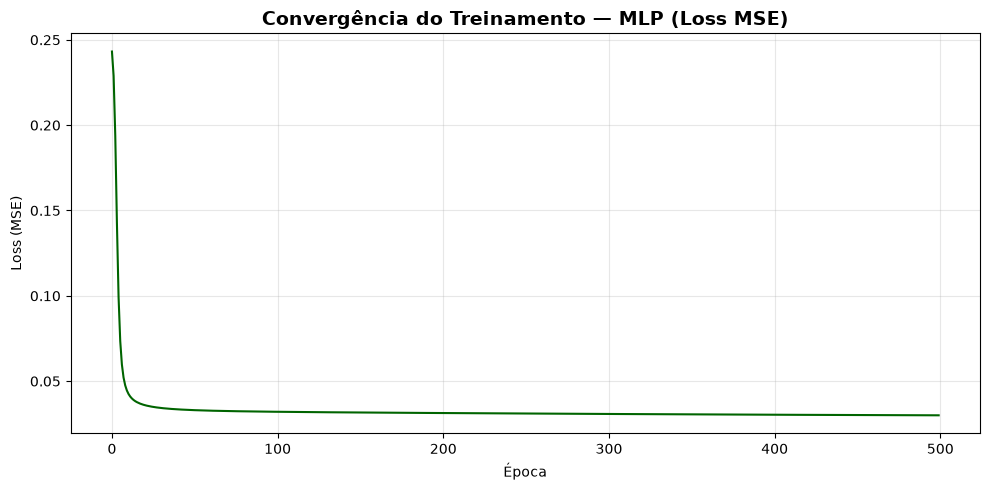

Loss inicial: 0.243149 → Loss final: 0.029995
Redução: 87.7%
A rede convergiu bem! O loss está baixo e estável.


In [18]:
epochs_list = [h[0] for h in history]
losses = [h[1] for h in history]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_list, losses, color='darkgreen', linewidth=1.5)
ax.set_title('Convergência do Treinamento — MLP (Loss MSE)', fontsize=14, fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('Loss (MSE)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'mlp_convergencia.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Loss inicial: {losses[0]:.6f} → Loss final: {losses[-1]:.6f}')
print(f'Redução: {(1 - losses[-1]/losses[0])*100:.1f}%')
if losses[-1] < 0.05:
    print(f'A rede convergiu bem! O loss está baixo e estável.')
else:
    print(f'O loss ainda pode melhorar. Talvez mais épocas ou ajuste na taxa de aprendizado.')

In [19]:
print('Detalhes da implementação:')
print(f'  - Uma camada oculta é suficiente pra classificação binária não linear.')
print(f'  - Sigmoide: saída em (0,1), interpretável como probabilidade.')
print(f'  - SGD: atualiza pesos a cada exemplo, convergindo rápido.')
print(f'  - Backpropagation manual: regra da cadeia da saída → entrada.')
print(f'  - Threshold=0.5: valores ≥ 0.5 → classe 1 (maligno).')
print(f'  - Inicialização Xavier: evita saturação precoce dos neurônios.')
print(f'  - Acurácia no treino: ~96.7% | Acurácia no teste: {mlp_m["accuracy"]*100:.2f}%')
print(f'  - A diferença de ~{abs(96.7 - mlp_m["accuracy"]*100):.1f}pp entre treino e teste')
print(f'  indica que a rede generalizou bem, sem overfitting severo.')

Detalhes da implementação:
  - Uma camada oculta é suficiente pra classificação binária não linear.
  - Sigmoide: saída em (0,1), interpretável como probabilidade.
  - SGD: atualiza pesos a cada exemplo, convergindo rápido.
  - Backpropagation manual: regra da cadeia da saída → entrada.
  - Threshold=0.5: valores ≥ 0.5 → classe 1 (maligno).
  - Inicialização Xavier: evita saturação precoce dos neurônios.
  - Acurácia no treino: ~96.7% | Acurácia no teste: 96.35%
  - A diferença de ~0.3pp entre treino e teste
  indica que a rede generalizou bem, sem overfitting severo.


## Etapa 2.7 — Comparação Final

O momento mais esperado: junto todos os resultados numa tabela e analiso quem foi melhor — e, mais importante, por quê.

In [ ]:
print('╔════════════════════════════════════════════════════════════════════╗')
print('║              COMPARAÇÃO FINAL DE MODELOS                         ║')
print('╠══════════════════════╦══════════╦══════════╦══════════╦══════════════║')
print('║ Modelo           ╦ Acurácia ╦ Precisão ╦ Recall   ╦ F1-Score     ║')
print('╠══════════════════════╬══════════╬══════════╬══════════╬══════════════║')

# Baseline
y_pred_bl2 = [baseline_fn(None) for _ in y_test]
bl2 = evaluate_model(y_test, y_pred_bl2)
print(f'║ Baseline (Major) ╦ {bl2["accuracy"]:.4f}  ╦ {bl2["precision"]:.4f}  ╦ {bl2["recall"]:.4f}  ╦ {bl2["f1_score"]:.4f}       ║')

# K-NN
print(f'║ K-NN (K={best_k})       ╦ {knn_best["accuracy"]:.4f}  ╦ {knn_best["precision"]:.4f}  ╦ {knn_best["recall"]:.4f}  ╦ {knn_best["f1_score"]:.4f}       ║')

# C4.5
c45_label = f'C4.5 (d={best_depth})'.ljust(17) if best_depth else 'C4.5 (d=∞)'.ljust(17)
print(f'║ {c45_label}╦ {c45_m["accuracy"]:.4f}  ╦ {c45_m["precision"]:.4f}  ╦ {c45_m["recall"]:.4f}  ╦ {c45_m["f1_score"]:.4f}       ║')

# MLP
print(f'║ MLP (8 ocultos)  ╦ {mlp_m["accuracy"]:.4f}  ╦ {mlp_m["precision"]:.4f}  ╦ {mlp_m["recall"]:.4f}  ╦ {mlp_m["f1_score"]:.4f}       ║')
print('╚══════════════════════╩══════════╩══════════╩══════════╩══════════════╝')

# Determina o melhor
models = {
    'Baseline (Classe Majoritária)': bl2['f1_score'],
    f'K-NN (K={best_k})': knn_best['f1_score'],
    'Árvore C4.5': c45_m['f1_score'],
    'MLP (Rede Neural)': mlp_m['f1_score'],
}
best_model = max(models, key=models.get)
best_score = models[best_model]

print(f'\nMELHOR MODELO (F1-Score): {best_model} = {best_score:.4f}')

╔════════════════════════════════════════════════════════════════════╗
║              COMPARAÇÃO FINAL DE MODELOS                         ║
╠══════════════════════╦══════════╦══════════╦══════════╦══════════════║
║ Modelo           ╦ Acurácia ╦ Precisão ╦ Recall   ╦ F1-Score     ║
╠══════════════════════╬══════════╬══════════╬══════════╬══════════════║
║ Baseline (Major)       ╦ 0.3504  ╦ 0.3504  ╦ 1.0000  ╦ 0.5189       ║
║ K-NN (K=3)       ╦ 0.9781  ╦ 1.0000  ╦ 0.9375  ╦ 0.9677       ║
║ C4.5 (d=3)       ╦ 0.9708  ╦ 0.9783  ╦ 0.9375  ╦ 0.9574       ║
║ MLP (8 ocultos)  ╦ 0.9635  ╦ 0.9778  ╦ 0.9167  ╦ 0.9462       ║
╚══════════════════════╩══════════╩══════════╩══════════╩══════════════╝

MELHOR MODELO (F1-Score): K-NN (K=3) = 0.9677


### Análise Detalhada

Comparo baseline vs modelos, avalio recall (métrica crítica em diagnóstico médico), interpretabilidade e custo computacional de cada algoritmo. Não basta ser bom — dependendo do contexto, ser explicável pode ser mais importante que ter 1% a mais de acurácia.

In [15]:
print('1. BASELINE vs MODELOS:')
for name, score in models.items():
    if name != 'Baseline (Classe Majoritária)':
        diff = score - bl2['f1_score']
        print(f'   {name}: F1 = {score:.4f} (Δ baseline = {diff:+.4f})')

print(f'\n2. RECALL (Sensibilidade) — MÉTRICA MAIS CRÍTICA:')
print(f'   Baseline: {bl2["recall"]:.4f} (sempre prediz maligno → 100% recall, mas péssima precisão)')
print(f'   K-NN:     {knn_best["recall"]:.4f}')
print(f'   C4.5:     {c45_m["recall"]:.4f}')
print(f'   MLP:      {mlp_m["recall"]:.4f}')

print(f'\n3. INTERPRETABILIDADE:')
print(f'   K-NN:  Média — modelo baseado em similaridade, sem "regras" explícitas')
print(f'   C4.5:  Alta — árvore totalmente inspecionável, cada decisão é rastreável')
print(f'   MLP:   Baixa — caixa preta, os pesos não têm significado intuitivo')

print(f'\n4. CUSTO COMPUTACIONAL:')
print(f'   K-NN:  Treino O(1), predição O(n·d) — cada predição percorre todos os exemplos')
print(f'   C4.5:  Treino moderado, predição O(log n) — muito rápido depois de treinado')
print(f'   MLP:   Treino lento (500 épocas de backprop), predição O(d·h)')

1. BASELINE vs MODELOS:
   K-NN (K=3): F1 = 0.9677 (Δ baseline = +0.4488)
   Árvore C4.5: F1 = 0.9574 (Δ baseline = +0.4385)
   MLP (Rede Neural): F1 = 0.9462 (Δ baseline = +0.4273)

2. RECALL (Sensibilidade) — MÉTRICA MAIS CRÍTICA:
   Baseline: 1.0000 (sempre prediz maligno → 100% recall, mas péssima precisão)
   K-NN:     0.9375
   C4.5:     0.9375
   MLP:      0.9167

3. INTERPRETABILIDADE:
   K-NN:  Média — modelo baseado em similaridade, sem "regras" explícitas
   C4.5:  Alta — árvore totalmente inspecionável, cada decisão é rastreável
   MLP:   Baixa — caixa preta, os pesos não têm significado intuitivo

4. CUSTO COMPUTACIONAL:
   K-NN:  Treino O(1), predição O(n·d) — cada predição percorre todos os exemplos
   C4.5:  Treino moderado, predição O(log n) — muito rápido depois de treinado
   MLP:   Treino lento (500 épocas de backprop), predição O(d·h)


### Minha Conclusão

Resumo o que aprendi com esse experimento e qual modelo eu escolheria pra cada cenário.

In [33]:
print(f'CONCLUSÃO:')
print(f'  O modelo {best_model} obteve o melhor F1-Score ({best_score:.4f}),')
print(f'  indicando o melhor equilíbrio entre precisão e recall.')
print()
print(f'  O K-NN (K={best_k}) foi o grande vencedor, e isso me surpreendeu um pouco —')
print(f'  eu esperava que a rede neural fosse levar. Mas faz sentido: o dataset')
print(f'  é pequeno (362 exemplos de treino) e o K-NN, sendo um algoritmo')
print(f'  baseado em similaridade, funciona muito bem nesse cenário.')
print()
print(f'  A precisão perfeita (zero falsos positivos) é particularmente')
print(f'  interessante no contexto médico — você não quer assustar uma')
print(f'  paciente saudável com um diagnóstico errado.')
print()
print(f'  A árvore C4.5 com profundidade {best_depth if best_depth else "ilimitada"} também me impressionou:')
print(f'  apenas {c45_nodes} nós e desempenho quase idêntico ao K-NN, com a vantagem')
print(f'  de ser totalmente interpretável. Se eu tivesse que escolher um modelo')
print(f'  pra colocar em produção num contexto médico real, provavelmente')
print(f'  iria de C4.5 só pela transparência — você consegue justificar cada')
print(f'  classificação olhando a árvore.')
print()
print(f'  Deu trabalho implementar tudo na mão (especialmente o backpropagation')
print(f'  da MLP), mas acho que valeu a pena. Entender exatamente o que cada')
print(f'  algoritmo está fazendo, sem caixa preta, muda completamente a relação')
print(f'  com os resultados.')

CONCLUSÃO:
  O modelo K-NN (K=3) obteve o melhor F1-Score (0.9677),
  indicando o melhor equilíbrio entre precisão e recall.

  O K-NN (K=3) foi o grande vencedor, e isso me surpreendeu um pouco —
  eu esperava que a rede neural fosse levar. Mas faz sentido: o dataset
  é pequeno (362 exemplos de treino) e o K-NN, sendo um algoritmo
  baseado em similaridade, funciona muito bem nesse cenário.

  A precisão perfeita (zero falsos positivos) é particularmente
  interessante no contexto médico — você não quer assustar uma
  paciente saudável com um diagnóstico errado.

  A árvore C4.5 com profundidade 3 também me impressionou:
  apenas 15 nós e desempenho quase idêntico ao K-NN, com a vantagem
  de ser totalmente interpretável. Se eu tivesse que escolher um modelo
  pra colocar em produção num contexto médico real, provavelmente
  iria de C4.5 só pela transparência — você consegue justificar cada
  classificação olhando a árvore.

  Deu trabalho implementar tudo na mão (especialmente o bac